# 07 — Product Ranking and Final Case Study Report

This notebook applies the selected model to the unseen test period, evaluates ranking quality, creates illustrative product rankings, and exports the final ShopSpark report.

## Install required packages

In [1]:
%pip install pandas numpy scikit-learn xgboost joblib matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in [current_dir, *current_dir.parents] if (path / "models" / "ensembles").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find models/ensembles. Run notebook 06 first.")

engineered_dir = project_root / "data" / "processed" / "engineered"
baseline_dir = project_root / "models" / "baselines"
ensemble_dir = project_root / "models" / "ensembles"
report_dir = project_root / "reports"
figure_dir = report_dir / "figures"
report_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

## Load the selected model and experiment results

In [3]:
with (ensemble_dir / "ensemble_metadata.json").open() as file:
    model_metadata = json.load(file)
with (engineered_dir / "feature_metadata.json").open() as file:
    feature_metadata = json.load(file)

preprocessor = joblib.load(ensemble_dir / "preprocessor.joblib")
best_model = joblib.load(ensemble_dir / "best_ensemble.joblib")
ensemble_results = pd.read_csv(ensemble_dir / "ensemble_validation_results.csv", index_col=0)
baseline_results = pd.read_csv(baseline_dir / "baseline_validation_results.csv", index_col=0)

selected_model_name = model_metadata["selected_model"]
selected_threshold = model_metadata["selected_threshold_from_validation"]
selected_derived_features = feature_metadata["selected_derived_features"]
display(Markdown(f"""**Selected model:** `{selected_model_name}`  
**Selection metric:** validation PR-AUC  
**Validation-selected threshold:** {selected_threshold:.4f}"""))

**Selected model:** `xgboost`  
**Selection metric:** validation PR-AUC  
**Validation-selected threshold:** 0.1602

## Recreate test-period click scores

In [4]:
test = pd.read_csv(engineered_dir / "test_top6_engineered.csv", parse_dates=["event_ts"])
target = "clicked"
numeric_features = [
    "slot_position", "hour_of_day", "price_usd", "discount_pct",
    "avg_rating", "review_count", "age", *selected_derived_features,
]
categorical_features = [
    "platform", "device_os", "page_type", "day_of_week",
    "brand", "category", "gender", "city", "loyalty_tier",
]
feature_columns = numeric_features + categorical_features

test.replace([np.inf, -np.inf], np.nan, inplace=True)
for column in categorical_features:
    test[column] = test[column].astype("string")
X_test = preprocessor.transform(test[feature_columns]).astype(np.float32)
y_test = test[target].astype("int8")
test_probability = best_model.predict_proba(X_test)[:, 1]

test_scored = test.copy()
test_scored["predicted_click_probability"] = test_probability
test_scored["predicted_click"] = (test_probability >= selected_threshold).astype("int8")
test_scored["score_decile"] = pd.qcut(
    test_scored["predicted_click_probability"].rank(method="first"),
    10, labels=range(1, 11),
).astype("int8")
display(test_scored[["impression_id", "user_id", "product_id", "clicked", "predicted_click_probability", "score_decile"]].head())

,impression_id,user_id,product_id,clicked,predicted_click_probability,score_decile
0,267820,5342,1169,0,0.4807,10
1,322397,2537,1019,0,0.4011,10
2,47773,6590,672,0,0.0087,1
3,298165,3188,31,0,0.0245,4
4,356995,2086,1044,0,0.0148,2


## Confirm final test performance

In [5]:
test_metrics = pd.Series({
    "PR-AUC": average_precision_score(y_test, test_probability),
    "ROC-AUC": roc_auc_score(y_test, test_probability),
    "Log loss": log_loss(y_test, test_probability),
    "Brier score": brier_score_loss(y_test, test_probability),
    "Overall CTR": y_test.mean(),
}, name="test result")
display(test_metrics.to_frame())

,test result
PR-AUC,0.2740
ROC-AUC,0.7951
Log loss,0.2133
Brier score,0.0581
Overall CTR,0.0706


## Rank impressions and calculate business lift

In [6]:
decile_summary = (
    test_scored.groupby("score_decile", observed=True)
    .agg(
        impressions=("impression_id", "size"),
        clicks=(target, "sum"),
        actual_ctr=(target, "mean"),
        average_predicted_probability=("predicted_click_probability", "mean"),
    )
    .sort_index(ascending=False)
)
decile_summary["ctr_lift"] = decile_summary["actual_ctr"] / y_test.mean()
decile_summary["click_capture_rate"] = decile_summary["clicks"] / y_test.sum()
decile_summary["cumulative_click_capture"] = decile_summary["click_capture_rate"].cumsum()
display(decile_summary)

top_decile = decile_summary.loc[10]
top_decile_ctr = float(top_decile["actual_ctr"])
top_decile_lift = float(top_decile["ctr_lift"])
top_decile_capture = float(top_decile["click_capture_rate"])
absolute_ctr_difference = top_decile_ctr - y_test.mean()

,impressions,clicks,actual_ctr,average_predicted_probability,ctr_lift,click_capture_rate,cumulative_click_capture
score_decile,,,,,,,
10,6750,1911,0.2831,0.2716,4.0113,0.4011,0.4011
9,6750,926,0.1372,0.1301,1.9437,0.1944,0.5955
8,6750,555,0.0822,0.0849,1.1650,0.1165,0.7120
7,6750,407,0.0603,0.0602,0.8543,0.0854,0.7974
6,6750,288,0.0427,0.0445,0.6045,0.0605,0.8579
5,6750,251,0.0372,0.0334,0.5269,0.0527,0.9106
4,6750,166,0.0246,0.0249,0.3484,0.0348,0.9454
3,6750,131,0.0194,0.0180,0.2750,0.0275,0.9729
2,6750,87,0.0129,0.0121,0.1826,0.0183,0.9912


## Plot ranking quality

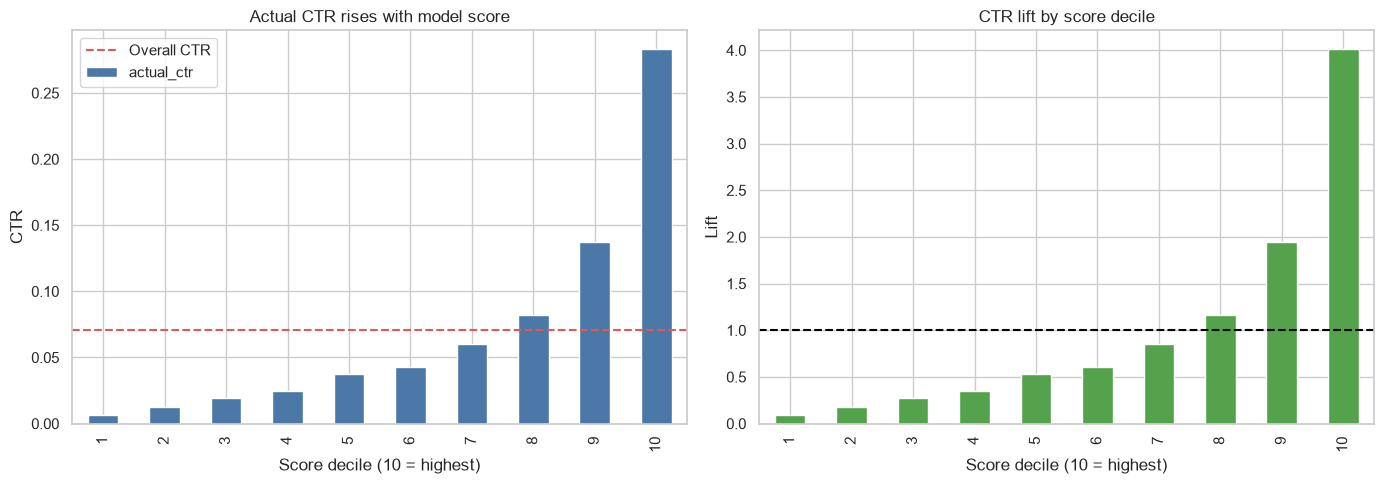

In [7]:
plot_data = decile_summary.sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_data["actual_ctr"].plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].axhline(y_test.mean(), color="#E45756", linestyle="--", label="Overall CTR")
axes[0].set(title="Actual CTR rises with model score", xlabel="Score decile (10 = highest)", ylabel="CTR")
axes[0].legend()
plot_data["ctr_lift"].plot(kind="bar", ax=axes[1], color="#54A24B")
axes[1].axhline(1, color="black", linestyle="--")
axes[1].set(title="CTR lift by score decile", xlabel="Score decile (10 = highest)", ylabel="Lift")
plt.tight_layout()
plt.savefig(figure_dir / "test_ranking_lift.png", dpi=150, bbox_inches="tight")
plt.show()

## Compare every baseline and ensemble model

,validation_pr_auc,validation_roc_auc,validation_log_loss,validation_brier_score,model_family
model,,,,,
xgboost,0.2825,0.8021,0.2100,0.0573,ensemble
hist_gradient_boosting,0.2783,0.7998,0.2109,0.0575,ensemble
random_forest,0.2688,0.7911,0.4630,0.1492,ensemble
decision_tree,0.2277,0.7643,0.5850,0.1981,baseline
logistic_regression,0.1985,0.7566,0.2249,0.0607,baseline
dummy,0.0701,0.5000,0.2539,0.0652,baseline


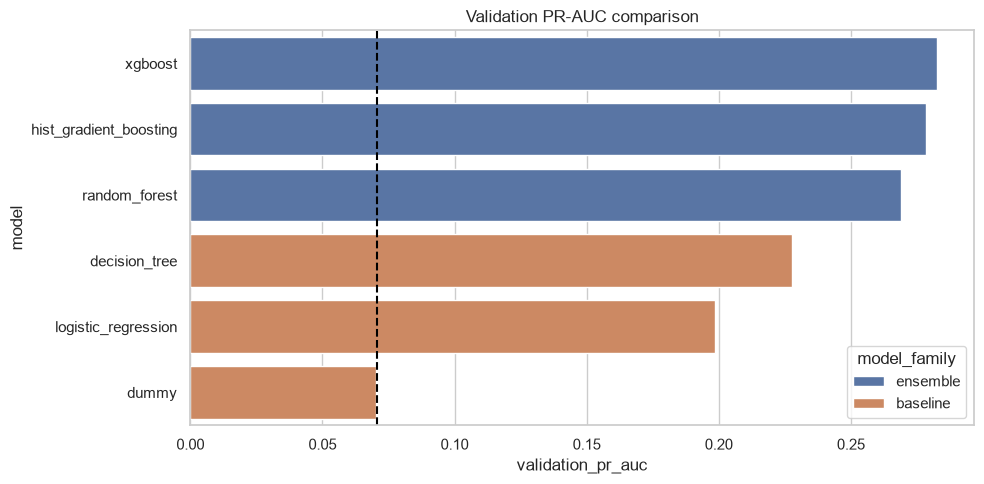

In [8]:
comparison_columns = ["validation_pr_auc", "validation_roc_auc", "validation_log_loss", "validation_brier_score"]
model_comparison = pd.concat([
    baseline_results[comparison_columns].assign(model_family="baseline"),
    ensemble_results[comparison_columns].assign(model_family="ensemble"),
]).sort_values("validation_pr_auc", ascending=False)
display(model_comparison)

plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison.reset_index(), x="validation_pr_auc", y="model", hue="model_family")
plt.axvline(y_test.mean(), color="black", linestyle="--", label="Test click rate")
plt.title("Validation PR-AUC comparison")
plt.tight_layout()
plt.savefig(figure_dir / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Create illustrative user–product rankings

For each user, the table below ranks unique products that appeared in that user's test impressions. This demonstrates the scoring output, but it is not a true counterfactual recommendation list because the dataset does not contain complete candidate sets for each request.

In [9]:
user_product_ranking = (
    test_scored.sort_values("predicted_click_probability", ascending=False)
    .drop_duplicates(["user_id", "product_id"])
    .groupby("user_id", group_keys=False)
    .head(3)
    .copy()
)
user_product_ranking["recommendation_rank"] = (
    user_product_ranking.groupby("user_id")["predicted_click_probability"]
    .rank(method="first", ascending=False)
    .astype("int8")
)
ranking_columns = [
    "user_id", "recommendation_rank", "product_id", "product_name",
    "brand", "category", "predicted_click_probability", "clicked",
]
user_product_ranking = user_product_ranking[ranking_columns].sort_values(["user_id", "recommendation_rank"])
display(user_product_ranking.head(30))

,user_id,recommendation_rank,product_id,product_name,brand,category,predicted_click_probability,clicked
23688,1,1,598,PepsiCo Value Pack Coffee Blend,PepsiCo,Grocery,0.0881,0
6810,1,2,572,Samsung Smartwatch SE,Samsung,Electronics,0.0754,0
62767,1,3,175,Cuisinart Everyday Storage Shelf,Cuisinart,Home,0.0451,0
1728,2,1,836,Sony Bluetooth Speaker Gen 2,Sony,Electronics,0.4521,1
11629,2,2,910,Samsung Wireless Earbuds SE,Samsung,Electronics,0.2859,0
15855,2,3,573,Tommy Hilfiger Everyday Running Jacket,Tommy Hilfiger,Fashion,0.1668,0
55218,3,1,608,Samsung Bluetooth Speaker Gen 2,Samsung,Electronics,0.2131,1
21911,3,2,879,Kraft Heinz Family Size Organic Soup Pack,Kraft Heinz,Grocery,0.1011,0
67193,3,3,752,General Mills Value Pack Organic Soup Pack,General Mills,Grocery,0.0861,0
33919,4,1,1135,Sony Smartwatch SE,Sony,Electronics,0.2850,0


## Review ranking performance across business segments

In [10]:
segment_rows = []
for column in ["platform", "page_type", "category", "loyalty_tier"]:
    for value, group in test_scored.groupby(column, dropna=False):
        if len(group) < 200 or group[target].nunique() < 2:
            continue
        segment_rows.append({
            "segment_type": column,
            "segment": value,
            "impressions": len(group),
            "actual_ctr": group[target].mean(),
            "pr_auc": average_precision_score(group[target], group["predicted_click_probability"]),
            "roc_auc": roc_auc_score(group[target], group["predicted_click_probability"]),
        })
segment_report = pd.DataFrame(segment_rows)
display(segment_report.sort_values(["segment_type", "pr_auc"], ascending=[True, False]))

,segment_type,segment,impressions,actual_ctr,pr_auc,roc_auc
9,category,Fashion,9335,0.1194,0.4010,0.8112
8,category,Electronics,11888,0.1103,0.2956,0.7725
10,category,Grocery,10659,0.0978,0.2526,0.7287
11,category,Home,8353,0.0570,0.1763,0.7647
12,category,Sports,7750,0.0409,0.1028,0.7072
6,category,Beauty,7543,0.0378,0.0828,0.6905
13,category,Toys,5472,0.0168,0.0471,0.7138
7,category,Books,6500,0.0194,0.0436,0.7089
16,loyalty_tier,Platinum,7412,0.0857,0.3122,0.7951
17,loyalty_tier,Silver,34659,0.0683,0.2699,0.7987


## Explain the winner with feature importance

Feature importance shows which inputs the selected model used most when separating likely clicks from non-clicks. It helps explain the model and check for suspicious leakage, but it does not prove that a feature causes clicks.

In [ ]:
encoded_feature_names = preprocessor.get_feature_names_out().tolist()
if not hasattr(best_model, "feature_importances_"):
    raise AttributeError(
        f"{selected_model_name} does not provide native feature importance. "
        "Use permutation importance for this model."
    )
if len(encoded_feature_names) != len(best_model.feature_importances_):
    raise ValueError("Feature names do not match the fitted model inputs.")

feature_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": best_model.feature_importances_,
})
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)
feature_importance["importance_pct"] = (
    100 * feature_importance["importance"] / feature_importance["importance"].sum()
)
feature_importance = feature_importance.sort_values("importance", ascending=False).reset_index(drop=True)
feature_importance["rank"] = np.arange(1, len(feature_importance) + 1)
top_feature_importance = feature_importance.head(20).copy()
display(top_feature_importance[["rank", "feature", "importance", "importance_pct"]])

plt.figure(figsize=(10, 8))
plot_importance = top_feature_importance.sort_values("importance")
plt.barh(plot_importance["feature"], plot_importance["importance"], color="#4C78A8")
plt.xlabel("XGBoost feature importance")
plt.ylabel("Feature")
plt.title(f"Top 20 features used by {selected_model_name}")
plt.tight_layout()
plt.savefig(figure_dir / "best_model_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpret the most important features

In [ ]:
top_five_features = top_feature_importance.head(5)["feature"].tolist()
top_five_share = top_feature_importance.head(5)["importance_pct"].sum()
historical_top_features = [
    feature for feature in top_five_features
    if any(term in feature for term in ["past", "ctr", "click"])
]

display(Markdown(f"""
### Feature-importance finding

- The five most important model inputs are **{', '.join(top_five_features)}**.
- Together they account for **{top_five_share:.2f}%** of the model's native importance.
- Historical behavior appears among the top features: **{', '.join(historical_top_features) if historical_top_features else 'none of the top five'}**.
- These results show what XGBoost used for prediction. They do not show whether increasing or decreasing a feature raises CTR, and they do not prove causation.
- A feature such as `product_past_ctr` is safe only because it was built from earlier clicks. The current click target was never used as an input.
- For direction and individual explanations, use SHAP values as a separate interpretation step.
"""))

## Export ranking outputs and final written report

In [11]:
test_scored.to_csv(report_dir / "test_scored_impressions.csv", index=False)
decile_summary.to_csv(report_dir / "ranking_decile_summary.csv")
user_product_ranking.to_csv(report_dir / "illustrative_user_product_rankings.csv", index=False)
segment_report.to_csv(report_dir / "segment_performance.csv", index=False)
model_comparison.to_csv(report_dir / "model_comparison.csv")
feature_importance.to_csv(report_dir / "best_model_feature_importance.csv", index=False)

best_validation_pr_auc = float(model_comparison.iloc[0]["validation_pr_auc"])
tree_validation_pr_auc = float(model_comparison.loc["decision_tree", "validation_pr_auc"])
relative_gain = (best_validation_pr_auc - tree_validation_pr_auc) / tree_validation_pr_auc

report_text = f"""# ShopSpark Click Prediction — Final Report

## Objective
Predict the probability that a user clicks a displayed product, then use that probability to prioritize products in recommendation slots.

## Data and validation design
The project used 450,000 impressions with a chronological 70% training, 15% validation, and 15% test split. The test period remained unavailable during model selection.

## Selected model
The selected model is **{selected_model_name}**, chosen using validation PR-AUC. Its validation PR-AUC was **{best_validation_pr_auc:.4f}**, a **{relative_gain:.2%} relative improvement** over the single decision tree.

## Final test performance
- PR-AUC: **{test_metrics['PR-AUC']:.4f}**
- ROC-AUC: **{test_metrics['ROC-AUC']:.4f}**
- Log loss: **{test_metrics['Log loss']:.4f}**
- Brier score: **{test_metrics['Brier score']:.4f}**

## Ranking result
The full test population had **{y_test.mean():.2%} CTR**. The highest-scored 10% achieved **{top_decile_ctr:.2%} CTR**, representing **{top_decile_lift:.2f}× lift** and capturing **{top_decile_capture:.2%} of all test clicks**.

## Model interpretation
The five most important model inputs were **{', '.join(top_five_features)}**. Native importance indicates which features the model used most, but it does not establish the direction of an effect or prove causation.

## Recommendation
Use the predicted click probability as the offline product-ranking score. Before deployment, add request IDs and complete eligible candidate sets, calibrate probabilities if needed, apply business constraints, and run an online A/B test against the current recommendation rules.

## Limitations
This is an observational offline evaluation. It demonstrates ranking quality but cannot prove causal CTR or revenue lift. The current data does not identify products competing in the same recommendation request.
"""
(report_dir / "final_case_study_report.md").write_text(report_text)
print(f"Final report saved to: {report_dir / 'final_case_study_report.md'}")

Final report saved to: /Users/namees.local/Desktop/ensamble_technique/reports/final_case_study_report.md


## Final case-study recap

In [12]:
display(Markdown(f"""
### Final answer for ShopSpark

- **Best model:** {selected_model_name}
- **Why it won:** it had the highest validation PR-AUC before test evaluation.
- **Unseen test PR-AUC:** {test_metrics['PR-AUC']:.4f}
- **Unseen test ROC-AUC:** {test_metrics['ROC-AUC']:.4f}
- **Overall test CTR:** {y_test.mean():.2%}
- **CTR among the highest-scored 10%:** {top_decile_ctr:.2%}
- **Top-10% CTR lift:** {top_decile_lift:.2f}×
- **Clicks captured by the highest-scored 10%:** {top_decile_capture:.2%}

The model successfully places more actual clicks near the top of its ranking. ShopSpark can use its predicted probability as a recommendation score, but true product reranking must be verified with request-level candidate data and an online A/B test.
"""))


### Final answer for ShopSpark

- **Best model:** xgboost
- **Why it won:** it had the highest validation PR-AUC before test evaluation.
- **Unseen test PR-AUC:** 0.2740
- **Unseen test ROC-AUC:** 0.7951
- **Overall test CTR:** 7.06%
- **CTR among the highest-scored 10%:** 28.31%
- **Top-10% CTR lift:** 4.01×
- **Clicks captured by the highest-scored 10%:** 40.11%

The model successfully places more actual clicks near the top of its ranking. ShopSpark can use its predicted probability as a recommendation score, but true product reranking must be verified with request-level candidate data and an online A/B test.
